<Figure size 1000x600 with 0 Axes>

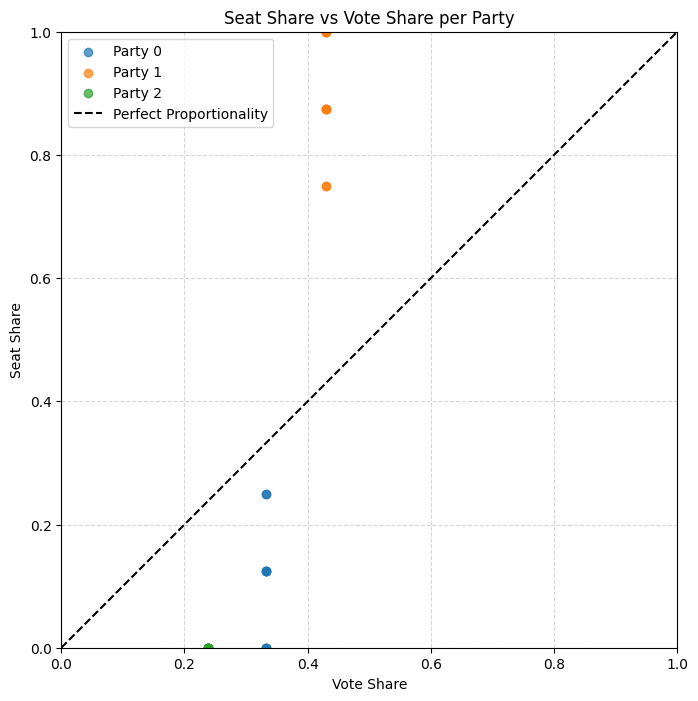


----- REDISTRICTING SUMMARY -----
Runs: 10
Party 0: Mean Vote Share = 0.333, Mean Seat Share = 0.100
Party 1: Mean Vote Share = 0.429, Mean Seat Share = 0.900
Party 2: Mean Vote Share = 0.238, Mean Seat Share = 0.000


In [2]:
          .  .  ssscsf  

In [3]:
import pandas as pd

# ------------------------------------------------------------
# GENERATE DETAILED DISTRICT-BY-DISTRICT WINNER TABLE
# ------------------------------------------------------------
detailed_results = []

for run_idx in range(NUM_RUNS):
    # Get the district counts for this specific simulation
    districts_in_run = all_district_counts[run_idx]
    
    for dist_idx, counts in enumerate(districts_in_run):
        # Identify the winner of this specific district
        winner = max(counts, key=counts.get)
        winner_votes = counts[winner]
        total_dist_votes = sum(counts.values())
        win_margin = winner_votes / total_dist_votes
        
        detailed_results.append({
            "Simulation": run_idx + 1,
            "District": dist_idx + 1,
            "Winner": winner,
            "Winner Votes": winner_votes,
            "Total Votes": total_dist_votes,
            "Win Margin %": f"{win_margin * 100:.1f}%"
        })

# Create the DataFrame
df_detailed = pd.DataFrame(detailed_results)

# Display options to ensure we can see the data clearly
pd.set_option('display.max_rows', 20) # Shows first and last 10 rows
print("\n--- DISTRICT-LEVEL WINNERS PER SIMULATION ---")
print(df_detailed.to_string(index=False))

# ------------------------------------------------------------
# OPTIONAL: Summary Table of "Total Wins" per Party
# ------------------------------------------------------------
print("\n--- TOTAL DISTRICTS WON ACROSS ALL RUNS ---")
print(df_detailed['Winner'].value_counts())


--- DISTRICT-LEVEL WINNERS PER SIMULATION ---
 Simulation  District  Winner  Winner Votes  Total Votes Win Margin %
          1         1 Party 1            62          125        49.6%
          1         2 Party 1            58          125        46.4%
          1         3 Party 1            52          125        41.6%
          1         4 Party 1            59          125        47.2%
          1         5 Party 1            59          125        47.2%
          1         6 Party 1            52          125        41.6%
          1         7 Party 1            48          125        38.4%
          1         8 Party 0            58          125        46.4%
          2         1 Party 1            54          125        43.2%
          2         2 Party 1            48          125        38.4%
          2         3 Party 1            56          125        44.8%
          2         4 Party 1            56          125        44.8%
          2         5 Party 1            51

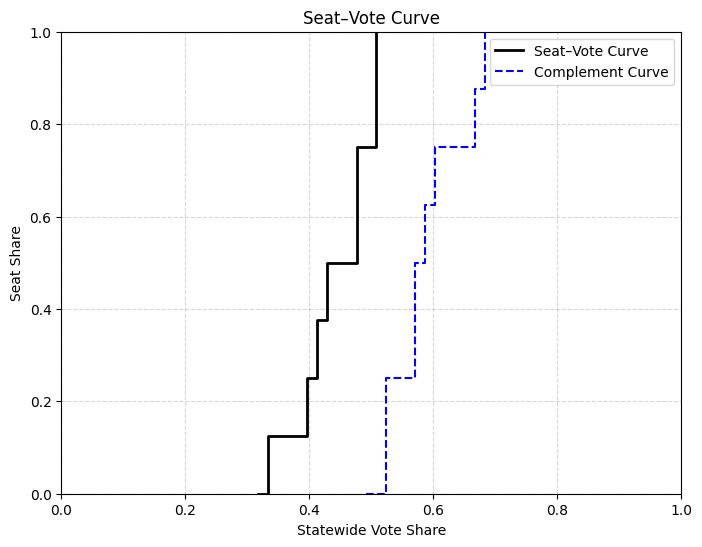

Area Step: 0.589
Area Complement: 0.369
Area Difference (Bias): 0.22
[[-0.3413333333333333, -0.4053333333333333, -0.5013333333333333, -0.3893333333333333, -0.3893333333333333, -0.5013333333333333, -0.5653333333333332, -0.4053333333333333], [-0.4693333333333333, -0.5653333333333332, -0.4373333333333333, -0.4373333333333333, -0.5173333333333333, -0.4053333333333333, -0.4693333333333333, -0.5013333333333333], [-0.4533333333333333, -0.6293333333333333, -0.4373333333333333, -0.42133333333333334, -0.4373333333333333, -0.4533333333333333, -0.4053333333333333, -0.4693333333333333], [-0.5333333333333332, -0.3893333333333333, -0.5013333333333333, -0.4533333333333333, -0.3733333333333333, -0.4693333333333333, -0.5333333333333332, -0.5493333333333332], [-0.48533333333333334, -0.42133333333333334, -0.5973333333333333, -0.4373333333333333, -0.42133333333333334, -0.5333333333333332, -0.35733333333333334, -0.5493333333333332], [-0.3733333333333333, -0.48533333333333334, -0.4533333333333333, -0.5173333

-0.4373333333333333

In [4]:
plot_step_and_complement(all_step_curves[9]["Party 0"], NUM_DISTRICTS)
# Access the dictionary for the first run, then the specific party
party_0_run_0_metrics = all_area_results[0]["Party 1"]

# Now you can print individual components
print("Area Step:", party_0_run_0_metrics["area_step"])
print("Area Complement:", party_0_run_0_metrics["area_complement"])
print("Area Difference (Bias):", party_0_run_0_metrics["area_between"])


print(all_efficiency_gaps)
all_efficiency_gaps[2][4]

In [5]:
# ------------------------------------------------------------
# RUN PAIRWISE SIMULATIONS
# ------------------------------------------------------------
pairwise_results = []
party_pairs = list(itertools.combinations(PARTY_IDS, 2))

for run_idx in range(NUM_RUNS):
    # (Assuming district_counts and curves are generated here as in your main code)
    # Get all party curves for this run
    current_curves = all_step_curves[run_idx] 
    
    for p1, p2 in party_pairs:
        area_gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
        
        pairwise_results.append({
            "Run": run_idx + 1,
            "Comparison": f"{p1} vs {p2}",
            "Area Gap": area_gap
        })

df_pairs = pd.DataFrame(pairwise_results)
print("\n--- PAIRWISE AREA DIFFERENCES ---")
print(df_pairs.head(20).to_string(index=False))



--- PAIRWISE AREA DIFFERENCES ---
 Run         Comparison  Area Gap
   1 Party 0 vs Party 1  0.052250
   1 Party 0 vs Party 2  0.022000
   1 Party 1 vs Party 2  0.058750
   2 Party 0 vs Party 1  0.048000
   2 Party 0 vs Party 2  0.031875
   2 Party 1 vs Party 2  0.044875
   3 Party 0 vs Party 1  0.045625
   3 Party 0 vs Party 2  0.025750
   3 Party 1 vs Party 2  0.052625
   4 Party 0 vs Party 1  0.045875
   4 Party 0 vs Party 2  0.039750
   4 Party 1 vs Party 2  0.050625
   5 Party 0 vs Party 1  0.049500
   5 Party 0 vs Party 2  0.018125
   5 Party 1 vs Party 2  0.052625
   6 Party 0 vs Party 1  0.044000
   6 Party 0 vs Party 2  0.028250
   6 Party 1 vs Party 2  0.052750
   7 Party 0 vs Party 1  0.045250
   7 Party 0 vs Party 2  0.035750


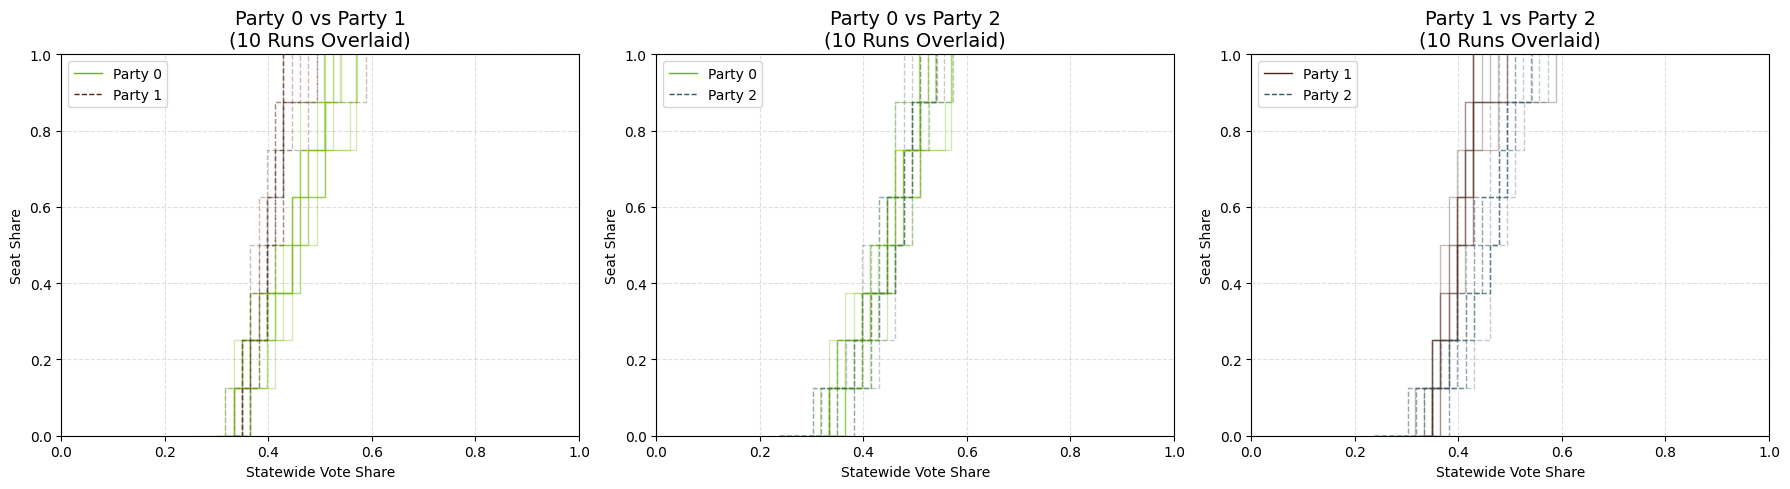

In [6]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_pairwise_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=20):
    """
    Creates one graph for each unique party pair.
    Each graph overlays multiple simulation runs to show the variance in bias.
    """
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    num_pairs = len(party_pairs)
    
    # Create a grid: 1 row, N columns (one for each pair)
    fig, axes = plt.subplots(1, num_pairs, figsize=(6 * num_pairs, 5), squeeze=False)
    
    # Determine how many runs to overlay
    runs_to_show = min(num_runs_to_plot, len(all_step_curves))

    for pair_idx, (party_a, party_b) in enumerate(party_pairs):
        ax = axes[0, pair_idx]
        
        for run_idx in range(runs_to_show):
            # Extract curves
            curve_a = all_step_curves[run_idx][party_a]
            curve_b = all_step_curves[run_idx][party_b]
            
            xa, ya = zip(*sorted(curve_a))
            xb, yb = zip(*sorted(curve_b))
            
            # Normalize to Seat Share
            ya_norm = np.array(ya) / NUM_DISTRICTS
            yb_norm = np.array(yb) / NUM_DISTRICTS
            
            # Use alpha (transparency) to handle the "overlay" effect
            # Only add a label for the first run so the legend isn't huge
            label_a = party_a if run_idx == 0 else None
            label_b = party_b if run_idx == 0 else None
            
            ax.step(xa, ya_norm, where='post', color=PARTY_COLORS[party_a], 
                    alpha=0.3, lw=1, label=label_a)
            ax.step(xb, yb_norm, where='post', color=PARTY_COLORS[party_b], 
                    alpha=0.3, lw=1, label=label_b, linestyle='--')

        # Formatting
        ax.set_title(f"{party_a} vs {party_b}\n({runs_to_show} Runs Overlaid)", fontsize=14)
        ax.set_xlabel("Statewide Vote Share")
        ax.set_ylabel("Seat Share")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.4)
        
        # Legend with opaque lines for clarity
        leg = ax.legend(loc='upper left')
        for lh in leg.legend_handles: 
            lh.set_alpha(1)

    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_pairwise_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=50)

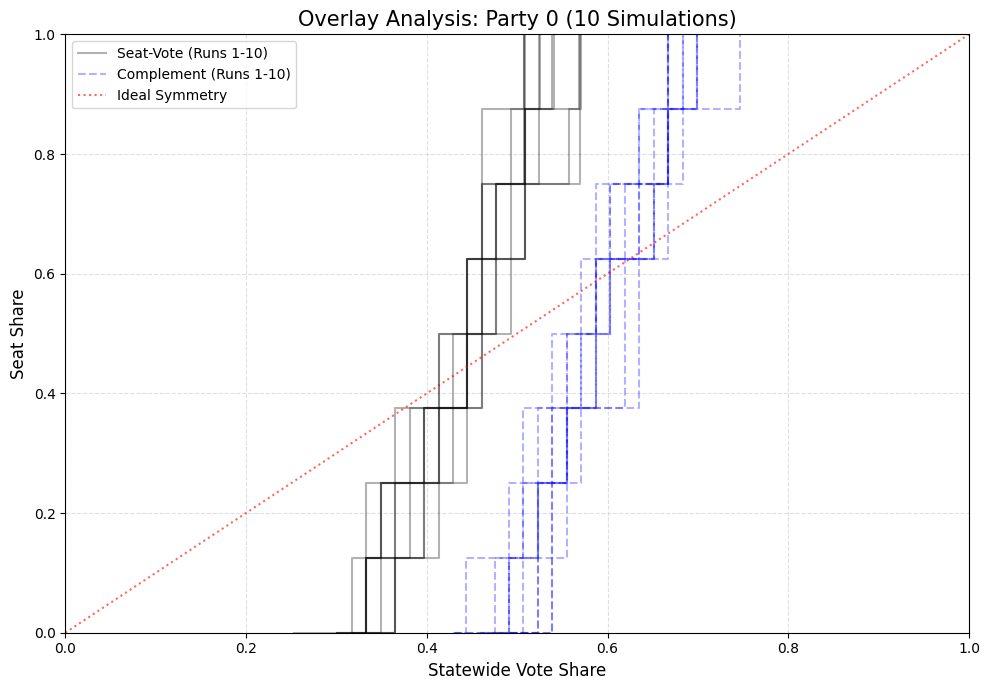

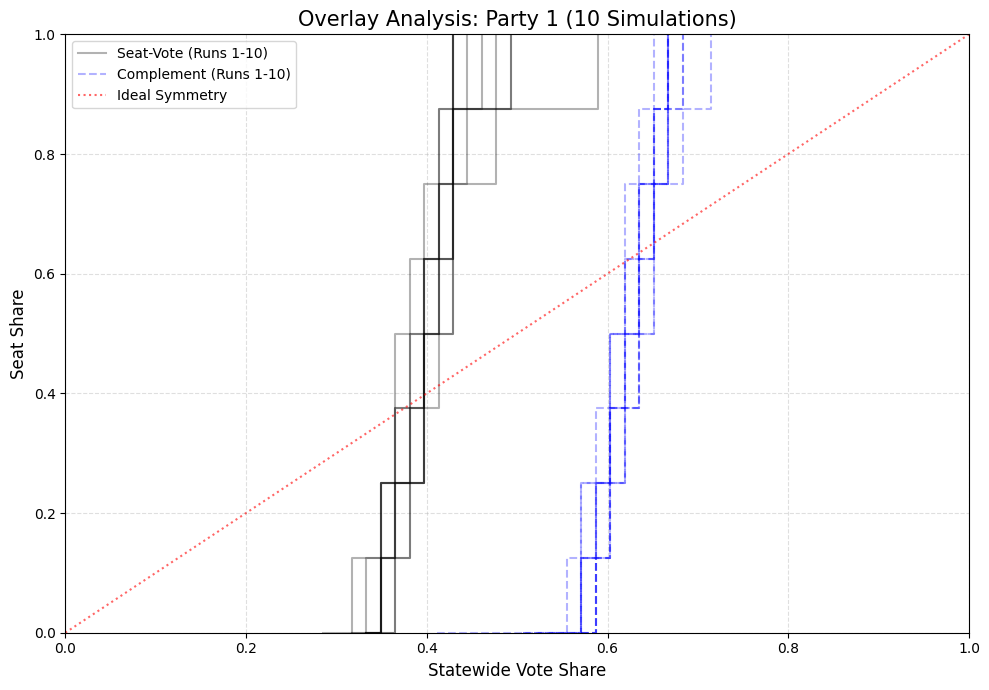

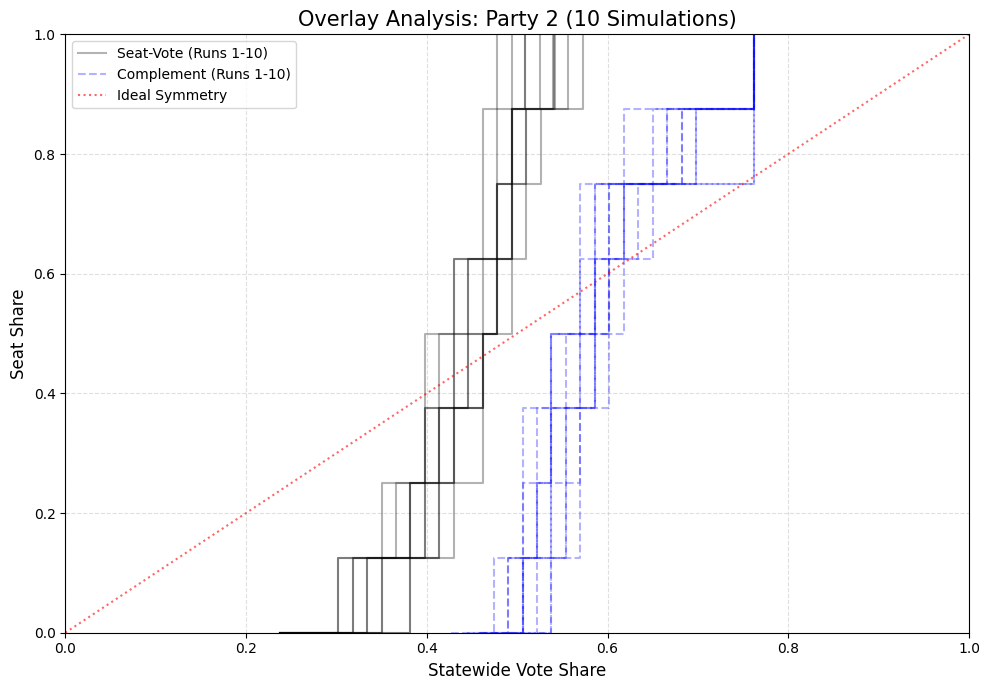

In [7]:
def plot_party_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=5):
    """
    Creates one figure per party, overlaying multiple simulation runs 
    of both the Seat-Vote and Complement curves.
    """
    num_districts = NUM_DISTRICTS # Uses global NUM_DISTRICTS
    
    for party in PARTY_IDS:
        plt.figure(figsize=(10, 7))
        
        # Determine how many runs we can actually plot
        runs_available = min(num_runs_to_plot, len(all_step_curves))
        
        for run_idx in range(runs_available):
            # 1. Extract data for this party in this run
            curve_points = all_step_curves[run_idx][party]
            x, y = zip(*sorted(curve_points))
            x = np.array(x)
            y = np.array(y) / num_districts  # Normalize to Seat Share (0-1)
            
            # 2. Calculate Complement coordinates: (1-x, 1-y)
            xc = 1 - x
            yc = 1 - y
            # Sort complement for step plotting
            c_order = np.argsort(xc)
            xc_sorted = xc[c_order]
            yc_sorted = yc[c_order]
            
            # 3. Plotting
            # We only want one label in the legend per group, not for every line
            label_sv = f"Seat-Vote (Runs 1-{runs_available})" if run_idx == 0 else None
            label_comp = f"Complement (Runs 1-{runs_available})" if run_idx == 0 else None
            
            # Plot Seat-Vote Curve (Solid)
            plt.step(x, y, where="post", color="black", alpha=0.3, lw=1.5, label=label_sv)
            
            # Plot Complement Curve (Dashed)
            plt.step(xc_sorted, yc_sorted, where="post", color="blue", 
                     linestyle="--", alpha=0.3, lw=1.5, label=label_comp)

        # Reference: Perfect Symmetry line
        plt.plot([0, 1], [0, 1], color="red", linestyle=":", alpha=0.6, label="Ideal Symmetry")

        # Formatting
        plt.title(f"Overlay Analysis: {party} ({runs_available} Simulations)", fontsize=15)
        plt.xlabel("Statewide Vote Share", fontsize=12)
        plt.ylabel("Seat Share", fontsize=12)
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend(loc="upper left")
        
        plt.tight_layout()
        plt.show()

# ------------------------
# EXECUTION
# ------------------------
plot_party_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=10)

#lets update the step curve so that the curves are compared between parties not x and 1-x and y and 1-y. 


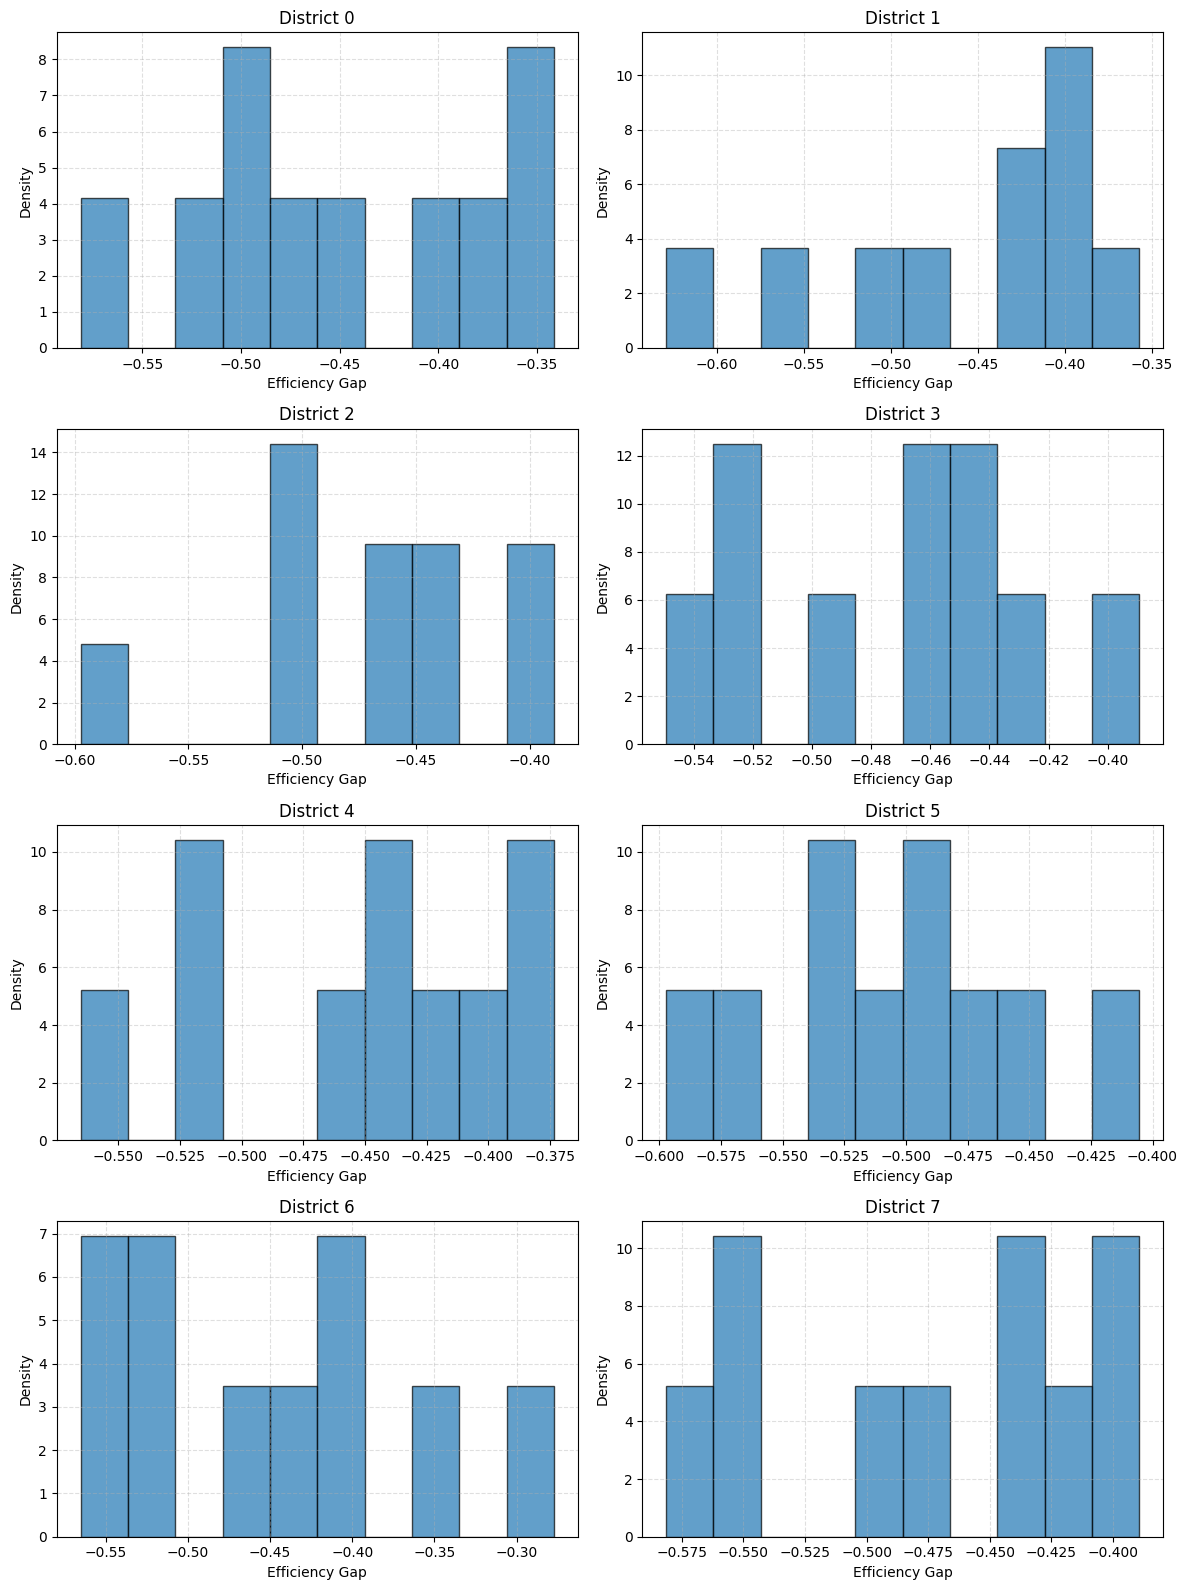

               Run 0     Run 1     Run 2     Run 3     Run 4     Run 5  \
District 0 -0.341333 -0.469333 -0.453333 -0.533333 -0.485333 -0.373333   
District 1 -0.405333 -0.565333 -0.629333 -0.389333 -0.421333 -0.485333   
District 2 -0.501333 -0.437333 -0.437333 -0.501333 -0.597333 -0.453333   
District 3 -0.389333 -0.437333 -0.421333 -0.453333 -0.437333 -0.517333   
District 4 -0.389333 -0.517333 -0.437333 -0.373333 -0.421333 -0.405333   
District 5 -0.501333 -0.405333 -0.453333 -0.469333 -0.533333 -0.597333   
District 6 -0.565333 -0.469333 -0.405333 -0.533333 -0.357333 -0.533333   
District 7 -0.405333 -0.501333 -0.469333 -0.549333 -0.549333 -0.437333   

               Run 6     Run 7     Run 8     Run 9  
District 0 -0.357333 -0.581333 -0.405333 -0.501333  
District 1 -0.501333 -0.357333 -0.437333 -0.389333  
District 2 -0.501333 -0.389333 -0.405333 -0.469333  
District 3 -0.549333 -0.533333 -0.501333 -0.453333  
District 4 -0.517333 -0.437333 -0.565333 -0.453333  
District 5 -0.5

In [8]:
import matplotlib.pyplot as plt
import math
import numpy as np

#Efficiency Gap Histograms per District

# Number of districts
n_districts = NUM_DISTRICTS

# Grid layout
n_cols = 2
n_rows = math.ceil(n_districts / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()

# Plot histograms
for d in range(n_districts):
    district_gaps = [all_efficiency_gaps[run][d] for run in range(NUM_RUNS)]
    
    axes[d].hist(district_gaps, bins=NUM_RUNS, edgecolor='black', alpha=0.7, density=True)
    axes[d].set_title(f"District {d}")
    axes[d].set_xlabel("Efficiency Gap")
    axes[d].set_ylabel("Density")
    #axes[d].set_ylim(0, 1)  # FIXED vertical axis
    axes[d].grid(True, linestyle="--", alpha=0.4)

# Remove empty subplots
for j in range(d+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
import pandas as pd

# all_efficiency_gaps is currently [run][district]

# Convert to DataFrame: rows=districts, columns=runs
df_efficiency = pd.DataFrame(all_efficiency_gaps).T

# Rename columns for clarity
df_efficiency.columns = [f"Run {i}" for i in range(NUM_RUNS)]
df_efficiency.index = [f"District {i}" for i in range(NUM_DISTRICTS)]

# Display
print(df_efficiency)



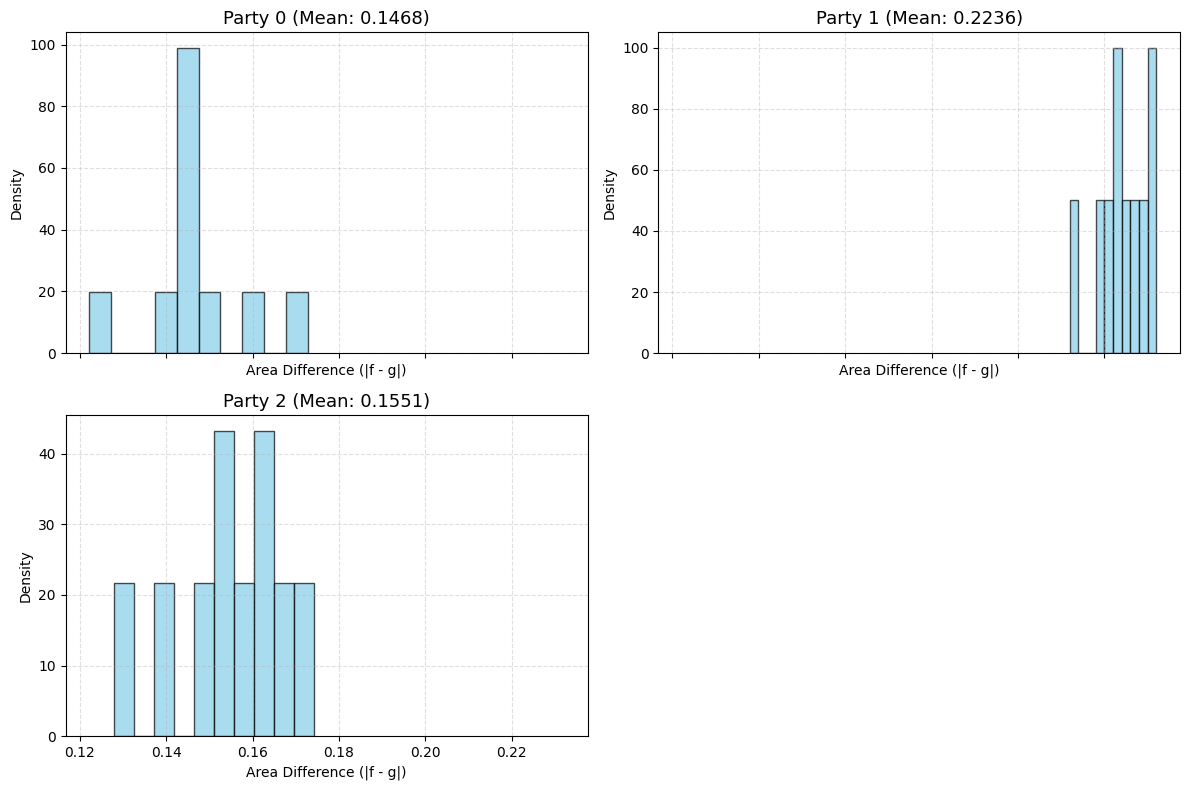

In [9]:

import matplotlib.pyplot as plt
import math
import numpy as np

# 1. First, collect all data and find the global maximum frequency
all_data_points = {}
max_freq = 0

for party in PARTY_IDS:
    # Extract area_between for this party
    data = [run[party]["area_between"] for run in all_area_results if party in run]
    all_data_points[party] = data
    
    if data:
        # Calculate a temporary histogram to find the max height for this party
        counts, _ = np.histogram(data, bins=10) # Using 10 bins as a standard for comparison
        max_freq = max(max_freq, np.max(counts))

# 2. Setup Grid Layout
n_parties = len(PARTY_IDS)
n_cols = 2
n_rows = math.ceil(n_parties / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharex=True)
axes = axes.flatten() if n_parties > 1 else [axes]

# 3. Plot with synchronized Y-axis
for i, party in enumerate(PARTY_IDS):
    data = all_data_points[party]
    
    if data:
        # Plot histogram
        axes[i].hist(data, bins=10, alpha=0.7, color='skyblue', edgecolor='black', density=True)
        
        # Calculate mean for title
        mean_val = np.mean(data)
        axes[i].set_title(f"{party} (Mean: {mean_val:.4f})", fontsize=13)
        
        # APPLY CONSISTENT Y-LIMIT
        # Adding 1 to max_freq gives a little breathing room at the top
        #axes[i].set_ylim(0, max_freq + 1)
        
        axes[i].set_xlabel("Area Difference (|f - g|)")
        axes[i].set_ylabel("Density")
        axes[i].grid(True, linestyle="--", alpha=0.4)

# Hide extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# GENERATE RUN-BY-RUN AREA DIFFERENCE TABLE WITH STATS
# ------------------------------------------------------------

# 1. First, build the raw data dictionary (keeping values as floats for math)
table_data = {"Party": PARTY_IDS}

# Create a list to help calculate row-wise stats later
all_values_matrix = []

for party in PARTY_IDS:
    party_row = []
    for run_idx in range(NUM_RUNS):
        area_val = all_area_results[run_idx][party]["area_between"]
        party_row.append(area_val)
    all_values_matrix.append(party_row)

# 2. Build the DataFrame
df_runs = pd.DataFrame(all_values_matrix, columns=[f"Run {i+1}" for i in range(NUM_RUNS)])

# 3. Add the Mean and Std Dev columns
df_runs["Mean"] = df_runs.mean(axis=1)
df_runs["Std Dev"] = df_runs.std(axis=1)

# 4. Insert the Party names at the start
df_runs.insert(0, "Party", PARTY_IDS)

# 5. Format for printing (round to 4 decimal places)
print("\n--- AREA DIFFERENCE PER SIMULATION (WITH STATS) ---")
print(df_runs.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 6. Transposed version (often easier to read with many runs)
# print("\n--- TRANSPOSED VIEW ---")
# print(df_runs.set_index("Party").T)


--- AREA DIFFERENCE PER SIMULATION (WITH STATS) ---
  Party  Run 1  Run 2  Run 3  Run 4  Run 5  Run 6  Run 7  Run 8  Run 9  Run 10   Mean  Std Dev
Party 0 0.1222 0.1580 0.1385 0.1461 0.1465 0.1440 0.1728 0.1461 0.1460  0.1482 0.1469   0.0122
Party 1 0.2200 0.2280 0.2180 0.2240 0.2320 0.2260 0.2220 0.2240 0.2300  0.2120 0.2236   0.0056
Party 2 0.1280 0.1601 0.1501 0.1641 0.1661 0.1520 0.1743 0.1623 0.1400  0.1541 0.1551   0.0128


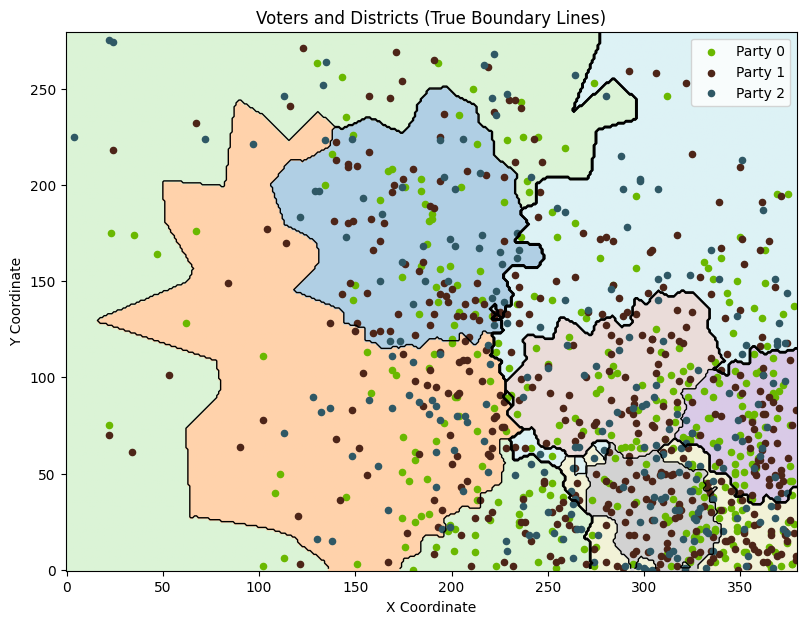

In [11]:
# ------------------------
# VISUALIZE ONE RUN (NO OVERLAP)
# ------------------------

district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng)

# Build KD-tree for fast nearest lookup
tree = cKDTree(voters)

# Create grid of every pixel
xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

# Assign each pixel to nearest voter
_, nearest_voter = tree.query(grid_points)
pixel_districts = district_labels[nearest_voter]
pixel_map = pixel_districts.reshape((HEIGHT, WIDTH))

plt.figure(figsize=(10,7))

# Lightly color districts
plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)

# Draw district boundaries
plt.contour(
    pixel_map,
    levels=np.arange(NUM_DISTRICTS)+0.5,
    colors='black',
    linewidths=1,
    origin='lower'
)

# Plot voters on top
for i, party in enumerate(PARTY_IDS):
    mask = voter_parties == i
    plt.scatter(
        voters[mask,0],
        voters[mask,1],
        color=PARTY_COLORS[party],
        label=party,
        s=20
    )

plt.title("Voters and Districts (True Boundary Lines)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()




## Wasted Vote Ratio Table

In addition to the efficiency gap, we compute a **wasted vote ratio** for each party in every simulation.

For party $p$:


$\text{Wasted Vote Ratio}_p =
\frac{\text{Total Wasted Votes}_p}{\text{Total Votes}}$


where

$
\text{Total Wasted Votes}_p =
\sum_{d=1}^{D} W_{p,d}
$

and

- $D$ = number of districts  
- $W_{p,d}$ = wasted votes for party $p$ in district $d$

After computing wasted votes for each district, we sum them across all districts.
This gives one total wasted votes number per party for the simulation run.

This produces a table with the following structure:

| Run | Party 0 | Party 1 | Party 2 |
|----|----|----|----|
| 1 | 0.13 | 0.29 | 0.25 |
| 2 | ... | ... | ... |

Each row represents a **different redistricting simulation**, while each column shows the **fraction of total votes that were wasted for that party**.

Higher wasted vote ratios indicate that a party's supporters are **either heavily concentrated in a few districts (packing)** or **spread thinly across many districts (cracking)**.

This table allows us to analyze how different district maps affect the **distribution of wasted votes across parties**.

In [12]:
# ------------------------------------------------------------
# WASTED VOTE RATIOS PER PARTY PER RUN
# ------------------------------------------------------------

wasted_vote_table = []

for run_idx in range(NUM_RUNS):

    district_counts = all_district_counts[run_idx]

    # Track wasted votes per party
    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:

        district_total = sum(district.values())
        total_votes += district_total

        # Winner of district
        winner = max(district, key=district.get)

        for party in PARTY_IDS:

            votes = district[party]

            if party == winner:
                wasted = votes - (district_total / NUM_PARTIES)
            else:
                wasted = votes

            wasted_votes[party] += wasted

    # Convert to ratios
    ratios = {party: wasted_votes[party] / total_votes for party in PARTY_IDS}

    row = {"Run": run_idx + 1}
    row.update(ratios)

    wasted_vote_table.append(row)

df_wasted = pd.DataFrame(wasted_vote_table)

print("\n--- WASTED VOTE RATIO (WASTED / TOTAL VOTES) ---")
print(df_wasted.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n--- MEAN WASTED VOTE RATIO ACROSS RUNS ---")
print(df_wasted.drop(columns="Run").mean())



# ------------------------------------------------------------
# EXPECTED WASTED VOTE RATIOS (ANALYTIC)
# ------------------------------------------------------------

# Compute total votes per party across all districts
total_votes_per_party = {party: 0 for party in PARTY_IDS}
total_votes_all = 0

# First, compute overall vote fractions
for district in all_district_counts[0]:  # use first run as representative
    district_total = sum(district.values())
    total_votes_all += district_total
    for party in PARTY_IDS:
        total_votes_per_party[party] += district[party]

# Compute vote shares
vote_shares = {party: total_votes_per_party[party] / total_votes_all for party in PARTY_IDS}

# Expected wasted vote ratios
expected_wasted = {}
for party in PARTY_IDS:
    p = vote_shares[party]
    expected_wasted[party] = (p * NUM_PARTIES - 1) / NUM_PARTIES  # approximate per-district formula

print("\n--- EXPECTED WASTED VOTE RATIO (ANALYTIC) ---")
for party, val in expected_wasted.items():
    print(f"Party {party}: {val:.4f}")


--- WASTED VOTE RATIO (WASTED / TOTAL VOTES) ---
 Run  Party 0  Party 1  Party 2
   1   0.2913   0.1373   0.2380
   2   0.3330   0.0957   0.2380
   3   0.2497   0.1790   0.2380
   4   0.3330   0.0957   0.2380
   5   0.3330   0.0957   0.2380
   6   0.3330   0.0957   0.2380
   7   0.2913   0.1373   0.2380
   8   0.2913   0.1373   0.2380
   9   0.2497   0.1790   0.2380
  10   0.2913   0.1373   0.2380

--- MEAN WASTED VOTE RATIO ACROSS RUNS ---
Party 0    0.299667
Party 1    0.129000
Party 2    0.238000
dtype: float64

--- EXPECTED WASTED VOTE RATIO (ANALYTIC) ---
Party Party 0: -0.0003
Party Party 1: 0.0957
Party Party 2: -0.0953


In [13]:
# ------------------------------------------------------------
# PAIRWISE EFFICIENCY GAP PER RUN
# ------------------------------------------------------------

import itertools

gap_rows = []

for run_idx in range(NUM_RUNS):

    district_counts = all_district_counts[run_idx]

    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:

        district_total = sum(district.values())
        total_votes += district_total

        winner = max(district, key=district.get)

        for party in PARTY_IDS:

            votes = district[party]

            if party == winner:
                wasted = votes - (district_total / NUM_PARTIES)
            else:
                wasted = votes

            wasted_votes[party] += wasted

    # --------------------------------------------------------
    # Compute pairwise gaps
    # --------------------------------------------------------
    for p1, p2 in itertools.combinations(PARTY_IDS, 2):

        gap_value = (wasted_votes[p1] - wasted_votes[p2]) / total_votes

        gap_rows.append({
            "Run": run_idx + 1,
            "Party A": p1,
            "Party B": p2,
            "Gap (A - B)": gap_value
        })

df_gap = pd.DataFrame(gap_rows)

print("\n--- PAIRWISE EFFICIENCY GAPS ---")
print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


--- PAIRWISE EFFICIENCY GAPS ---
 Run Party A Party B  Gap (A - B)
   1 Party 0 Party 1       0.1540
   1 Party 0 Party 2       0.0533
   1 Party 1 Party 2      -0.1007
   2 Party 0 Party 1       0.2373
   2 Party 0 Party 2       0.0950
   2 Party 1 Party 2      -0.1423
   3 Party 0 Party 1       0.0707
   3 Party 0 Party 2       0.0117
   3 Party 1 Party 2      -0.0590
   4 Party 0 Party 1       0.2373
   4 Party 0 Party 2       0.0950
   4 Party 1 Party 2      -0.1423
   5 Party 0 Party 1       0.2373
   5 Party 0 Party 2       0.0950
   5 Party 1 Party 2      -0.1423
   6 Party 0 Party 1       0.2373
   6 Party 0 Party 2       0.0950
   6 Party 1 Party 2      -0.1423
   7 Party 0 Party 1       0.1540
   7 Party 0 Party 2       0.0533
   7 Party 1 Party 2      -0.1007
   8 Party 0 Party 1       0.1540
   8 Party 0 Party 2       0.0533
   8 Party 1 Party 2      -0.1007
   9 Party 0 Party 1       0.0707
   9 Party 0 Party 2       0.0117
   9 Party 1 Party 2      -0.0590
  10 Party 0 P

## Efficiency Gap

The **Efficiency Gap (EG)** is a common metric used to detect partisan bias in districting plans.  
It measures the difference in **wasted votes** between political parties.

A **wasted vote** is defined as:

- **For the winning party:**  
  votes beyond the threshold needed to win.
- **For losing parties:**  
  all votes cast for that party.

For a district with total votes \(V\) and \(n\) parties:

- Winning party wasted votes:
  
$
W_{\text{winner}} = v_{\text{winner}} - \frac{V}{n}
$

- Losing party wasted votes:

$
W_{\text{loser}} = v_{\text{loser}}
$

The **Efficiency Gap** compares wasted votes between parties:

$
EG = \frac{W_A - W_B}{\text{Total Votes}}
$

where

- \(W_A\) = total wasted votes for Party A  
- \(W_B\) = total wasted votes for Party B  

Interpretation:

- **Positive EG:** Party A is advantaged
- **Negative EG:** Party B is advantaged
- **EG ≈ 0:** the districting plan is approximately symmetric

In this project the efficiency gap is computed **per district for each redistricting simulation**.

---


In [14]:
# ------------------------------------------------------------
# MAJORITY PARTY EFFICIENCY GAP PER RUN
# ------------------------------------------------------------

gap_rows = []

for run_idx in range(NUM_RUNS):

    district_counts = all_district_counts[run_idx]

    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:

        district_total = sum(district.values())
        total_votes += district_total

        winner = max(district, key=district.get)

        for party in PARTY_IDS:

            votes = district[party]

            if party == winner:
                wasted = votes - (district_total / NUM_PARTIES)
            else:
                wasted = votes

            wasted_votes[party] += wasted

    # Majority party
    majority_party = max(wasted_votes, key=wasted_votes.get)

    wasted_majority = wasted_votes[majority_party]
    wasted_others = sum(v for p, v in wasted_votes.items() if p != majority_party)

    gap_value = (wasted_majority - wasted_others) / total_votes

    gap_rows.append({
        "Run": run_idx + 1,
        "Majority Party": majority_party,
        "Gap": gap_value
    })

df_gap = pd.DataFrame(gap_rows)

print("\n--- MAJORITY PARTY EFFICIENCY GAP ---")
print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


--- MAJORITY PARTY EFFICIENCY GAP ---
 Run Majority Party     Gap
   1        Party 0 -0.0840
   2        Party 0 -0.0007
   3        Party 0 -0.1673
   4        Party 0 -0.0007
   5        Party 0 -0.0007
   6        Party 0 -0.0007
   7        Party 0 -0.0840
   8        Party 0 -0.0840
   9        Party 0 -0.1673
  10        Party 0 -0.0840


# Efficiency Gap (EG)

The **Efficiency Gap** measures **partisan bias** in electoral district maps. It shows how efficiently each party converts votes into seats.

---

## 1. Concept

- Ideally, a party's **seat share** ≈ its **vote share**.
- **Wasted votes** = votes that do **not contribute to winning a seat**:

  1. **Lost votes**: All votes for a losing candidate.
  2. **Excess votes**: Votes for a winning candidate beyond the majority threshold.

**Example (single district, 2-party):**

| Party | Votes | Wasted Votes |
|-------|-------|--------------|
| A     | 60    | 10 (=60 - 51)|
| B     | 40    | 40           |

- Total votes = 100
- Efficiency Gap (EG):

$
EG = \frac{\text{Wasted votes (Party A)} - \text{Wasted votes (Party B)}}{\text{Total votes}}
$

- Positive → favors Party A  
- Negative → favors Party B  

---

## 2. Multi-Party Generalization

For **N parties**, define wasted votes as:

- **Winner**: votes beyond the **majority threshold**

$
\text{Excess votes} = \text{votes} - \left(votes_{2ndWinner} + 1\right)
$

- **Losers**: all their votes are wasted.

**Efficiency Gap per party**:

$
EG_{\text{party}} = \frac{\text{Wasted votes}_{\text{party}} - \text{Wasted votes}_{\text{others}}}{\text{Total votes}}
$

---

## 3. Visualization Example (3-Party District)

| Party | Votes | Winner? | Wasted Votes |
|-------|-------|---------|--------------|
| A     | 45    | ❌       | 45           |
| B     | 30    | ❌       | 30           |
| C     | 25    | ✅       | 25 - 51 = -26 → 0? Adjusted to 0 |


In [15]:
# ------------------------------------------------------------
# RELIABLE MULTI‑PARTY EFFICIENCY GAP USING NEXT HIGHEST + 1
# ------------------------------------------------------------

gap_rows = []

for run_idx in range(NUM_RUNS):
    district_counts = all_district_counts[run_idx]

    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:
        district_total = sum(district.values())
        total_votes += district_total

        # Identify winner and runner‑up
        # Winner: highest votes; Runner‑up: second highest (or 0 if none)
        sorted_parties = sorted(district.items(), key=lambda x: x[1], reverse=True)
        winner, winner_votes = sorted_parties[0]
        runner_up_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0

        # Minimum votes needed to win = runner_up_votes + 1
        needed_to_win = runner_up_votes + 1

        for party in PARTY_IDS:
            votes = district[party]
            if party == winner:
                # Excess beyond what was needed to just beat runner‑up
                wasted = max(0, votes - needed_to_win)
            else:
                # All losing votes are wasted
                wasted = votes

            wasted_votes[party] += wasted

    # Compute efficiency gap for each party
    for party in PARTY_IDS:
        others_wasted = sum(v for p, v in wasted_votes.items() if p != party)
        gap_value = (wasted_votes[party] - others_wasted) / total_votes

        gap_rows.append({
            "Run": run_idx + 1,
            "Party": party,
            "Efficiency_Gap": gap_value
        })

df_gap = pd.DataFrame(gap_rows)

print("\n--- EFFICIENCY GAP PER PARTY (NEXT HIGHEST +1) ---")
print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


--- EFFICIENCY GAP PER PARTY (NEXT HIGHEST +1) ---
 Run   Party  Efficiency_Gap
   1 Party 0         -0.0890
   1 Party 1         -0.3870
   1 Party 2         -0.1990
   2 Party 0          0.0070
   2 Party 1         -0.4830
   2 Party 2         -0.1830
   3 Party 0         -0.1840
   3 Party 1         -0.2920
   3 Party 2         -0.1880
   4 Party 0          0.0100
   4 Party 1         -0.4860
   4 Party 2         -0.1800
   5 Party 0          0.0070
   5 Party 1         -0.4830
   5 Party 2         -0.1830
   6 Party 0          0.0070
   6 Party 1         -0.4830
   6 Party 2         -0.1830
   7 Party 0         -0.0930
   7 Party 1         -0.3830
   7 Party 2         -0.1890
   8 Party 0         -0.0910
   8 Party 1         -0.3850
   8 Party 2         -0.1850
   9 Party 0         -0.1940
   9 Party 1         -0.2820
   9 Party 2         -0.1920
  10 Party 0         -0.0910
  10 Party 1         -0.3850
  10 Party 2         -0.1770


In [16]:
print(np.bincount(district_labels))

[125 125 125 125 125 125 125 125]


# Efficiency Gap in Multi-Party Elections

The **Efficiency Gap (EG)** is a metric to quantify partisan bias in district-based elections. It measures how many votes are “wasted” by each party and compares the totals to identify unfair advantages.

---

## 1. Wasted Votes

For each district:

1. **Winning party**:  
   - Only the votes **needed to win** count as effective.  
   - All votes **beyond the minimum required to beat the next-highest party by one vote** are considered **excess votes** (wasted).  
   $
   \text{Wasted votes}_\text{winner} = \text{Votes}_\text{winner} - (\text{Votes}_\text{second place} + 1)
   $

2. **Losing parties**:  
   - Every vote cast for a party that does not win is wasted.  
   $
   \text{Wasted votes}_\text{loser} = \text{Votes}_\text{loser}
   $

This ensures that wasted votes are **adaptive** to the actual vote distribution in each district, rather than relying on fixed thresholds.

---

## 2. Total Wasted Votes

After computing wasted votes for every district:

$
W_p = \sum_{\text{all districts}} \text{Wasted votes for party } p
$

where \(p\) is any party participating in the election.

---

## 3. Efficiency Gap

The **Efficiency Gap** compares the wasted votes of the party with the **largest total wasted votes** (the “majority” or advantaged party) to all other parties:

$
\text{EG} = \frac{ W_\text{majority} - \sum_{\text{others}} W_p }{ \text{Total votes} }
$

- **Positive EG**: the majority party benefits (fewer wasted votes relative to others).  
- **Negative EG**: the majority party is disadvantaged.

---

## 4. Advantages of this N-Party Approach

- Works for **any number of parties**.
- Uses a **dynamic threshold** for excess votes (next-highest + 1), making it sensitive to actual vote counts.
- Accurately reflects **wasted vote asymmetries**, even in multi-party elections.
- Prevents misleading uniform results when districts are similar.

---

### Example

| District | Party 0 | Party 1 | Party 2 | Winner | Wasted Votes (P0/P1/P2) |
|----------|---------|---------|---------|--------|------------------------|
| 1        | 40      | 30      | 25      | 0      | 11 / 30 / 25           |
| 2        | 35      | 45      | 20      | 1      | 35 / 25 / 20           |

- Party 0 in District 1: needed 31 votes to beat Party 1 (30 + 1), so **excess = 40 − 31 = 9** (wasted).  
- Party 1 in District 1: lost, all 30 votes wasted.  
- Party 2 in District 1: lost, all 25 votes wasted.  

The total EG is computed using these wasted votes across all districts.

---

This method ensures that the efficiency gap remains a **reliable measure of fairness** even when there are more than two parties in the election.

In [17]:
gap_rows = []

for run_idx in range(NUM_RUNS):

    district_counts = all_district_counts[run_idx]
    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:
        district_total = sum(district.values())
        total_votes += district_total

        # Sort parties by votes descending
        sorted_parties = sorted(district.items(), key=lambda x: x[1], reverse=True)
        winner, winner_votes = sorted_parties[0]
        next_highest_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0

        # Winning party: votes beyond what was needed to win
        wasted_votes[winner] += winner_votes - (next_highest_votes + 1)

        # Losing parties: all votes wasted
        for party, votes in district.items():
            if party != winner:
                wasted_votes[party] += votes

    # Majority party by total wasted votes
    majority_party = max(wasted_votes, key=wasted_votes.get)
    gap_value = (wasted_votes[majority_party] - sum(v for p, v in wasted_votes.items() if p != majority_party)) / total_votes

    gap_rows.append({
        "Run": run_idx + 1,
        "Majority Party": majority_party,
        "Gap": gap_value
    })

df_gap = pd.DataFrame(gap_rows)
print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

 Run Majority Party     Gap
   1        Party 0 -0.0890
   2        Party 0  0.0070
   3        Party 0 -0.1850
   4        Party 0  0.0100
   5        Party 0  0.0070
   6        Party 0  0.0070
   7        Party 0 -0.0930
   8        Party 0 -0.0910
   9        Party 2 -0.1920
  10        Party 0 -0.0910


In [18]:

#export_full_simulation_data(all_district_counts, all_step_curves, PARTY_IDS, filename="gerrymandering_data.xlsx")